In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

from projects.flat_band_cooling import helper_fns as hpfn

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [ ]:
V_rsv_offsets = np.linspace(-3., 2., 6)
lattice_str = "kagome"
lattice_len = 20
sys_len = 12
runnum = 1                      # e.g. runnum 2 will look at all the 2nd copy (folders with suffix _002)
param_dict = {                  # Additional parameters I have included so far
    # "Vran": 0.05,                # Random offset on each site (value specifies standard deviation)
    # "tnnn": -0.01,              # Next nearest neighbour hopping
    # "lres": 0.5,                # Resolution of the box potential (in units of lattice cell size)
    }

data_folder = Path(E9path, "projects", "flat_band_cooling", "eigvals_library")

# Plot energies of all eigenstates

kagome_lat20x20_sys12x12_Vrsv-3p0000
kagome_lat20x20_sys12x12_Vrsv-2p0000
kagome_lat20x20_sys12x12_Vrsv-1p0000
kagome_lat20x20_sys12x12_Vrsv0p0000
kagome_lat20x20_sys12x12_Vrsv1p0000
kagome_lat20x20_sys12x12_Vrsv2p0000


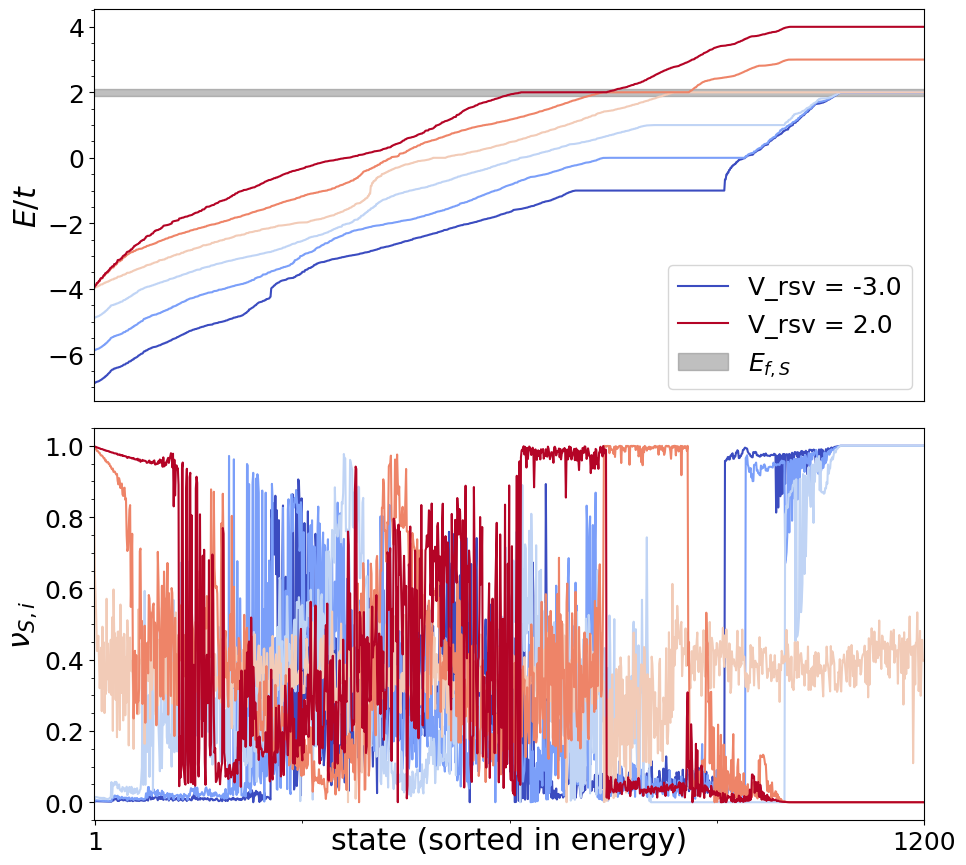

In [ ]:
lattice_dim = (lattice_len, lattice_len)
# lattice_dim = (lattice_len, 1)

fig_Es = plt.figure(figsize = (10, 9))
ax_Es = fig_Es.add_subplot(211)
ax_nus = fig_Es.add_subplot(212)
ax_Es.clear()
ax_nus.clear()
cmap = plt.get_cmap('coolwarm')

for V_rsv in V_rsv_offsets:
    folder_name = hpfn.get_model_str(lattice_str, lattice_dim, sys_len, V_rsv, runnum, param_dict)
    print(folder_name)
    with open(Path(data_folder, lattice_str, folder_name, "np_arrays.npz"), 'rb') as f:
        loaded_arrs_dict = np.load(f)
        eigvals = loaded_arrs_dict["eigvals"]
        density_sys = loaded_arrs_dict["density_sys"]
    color = util.get_color(V_rsv, V_rsv_offsets, cmap, assignment = "value")
    if (V_rsv == V_rsv_offsets[0]) or (V_rsv == V_rsv_offsets[-1]):
        label_str = f"V_rsv = {V_rsv}"
    else:
        label_str = ""
    ax_Es.plot(eigvals, label = label_str, color = color)
    ax_nus.plot(density_sys, color = color)

xmin, xmax = 0, len(eigvals)
ax_Es.fill_between([xmin, xmax], 1.9, 2.1, color = "gray", alpha = 0.5, label = r"$E_{f, S}$")
ax_Es.legend()
ax_Es.set_xlim(xmin, xmax)
ax_Es.set_xticks([])
ax_Es.set_ylabel(r"$E / t$")
ax_nus.set_xlim(xmin, xmax)
ax_nus.set_xticks([1, 1200])
ax_nus.ticklabel_format(style='plain')
ax_nus.set_xlabel("state (sorted in energy)", labelpad = -20)
ax_nus.set_ylabel(r"$\nu_{S, i}$")
# fig_Es.suptitle(f"{lattice_str}, lattice size {lattice_dim}, system size {sys_len}x{sys_len}")

fig_Es.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "finite_tb_nuS.pdf")
# fig_Es.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')